# AcademyInfo 단일 실행 검증

## tl;dr

이 노트북 하나가 대학알리미 API 설정과 실제 응답을 검증한다. 실행 시 과거 응답이나 중간 manifest를 읽지 않고 공식 API를 새로 호출하며, 응답은 메모리에서만 검사한다.

- 입력: `.env`, `config/academyinfo/endpoints.yaml`, `config/academyinfo/runtime.yaml`
- 공통 코드: `src/academyinfo/client.py`, `src/academyinfo/validation.py`
- 명령행 실행: `scripts/validate_academyinfo.py`
- 범위: 9개 서비스·103개 기능의 1행 probe
- 추가 검사: 대학명·학교코드·연도 생략, 다중 학교코드, 학과정보 페이지 경계, 동시성 4
- 산출물: 실행 결과가 포함된 이 노트북 하나뿐이며 `data/raw/`나 `data/metadata/`에 파일을 만들지 않는다.

## Context & Methods

이 검증은 수집 전에 API의 현재 동작과 수집 전략을 확인하는 진단이다. 103개 기능마다 대표 범위에서 `numOfRows=1`만 요청하므로 전체 데이터 수집이나 내용 완전성 검증을 대신하지 않는다.

### Key Assumptions

- 대표 조사연도는 2025년, 대표 학교는 제주대학교(`0000027`)다.
- 지역별 통계의 대표 학교구분은 `01`이다.
- HTTP 200, XML 파싱 성공, `resultCode=00`, 유효한 `totalCount`를 기능 가용성 기준으로 삼는다.
- 정상 0건은 실패가 아니다.
- 인증키는 `.env`에서만 읽고 URL·출력·파일에 기록하지 않는다.

## Data

### 1. 설정과 인증키를 읽는다

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
from IPython.display import Markdown, display

working_directory = Path.cwd().resolve()
REPO_ROOT = working_directory.parent if working_directory.name == "notebooks" else working_directory
SRC_DIR = REPO_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from academyinfo import ProbeDefaults, load_validation_context, run_validation

context = load_validation_context(
    REPO_ROOT / ".env",
    REPO_ROOT / "config" / "academyinfo" / "endpoints.yaml",
    REPO_ROOT / "config" / "academyinfo" / "runtime.yaml",
)
defaults = ProbeDefaults()

print("입력 확인: .env + config 2개 + src/academyinfo")
print(f"검증 범위: {len({item['service'] for item in context.endpoints})}개 서비스 / {len(context.endpoints)}개 기능")
print("인증키: 로드됨(값은 표시하지 않음)")

입력 확인: .env + config 2개 + src/academyinfo
검증 범위: 9개 서비스 / 103개 기능
인증키: 로드됨(값은 표시하지 않음)


### 2. 공통 검증 흐름을 한 번 실행한다

103개 probe, 연도·학교 생략, 다중 학교코드, 학과정보 페이지 경계, 동시성 검사는 `src/academyinfo/validation.py`의 `run_validation()`이 수행한다.

In [2]:
validation = run_validation(context, defaults=defaults, progress=print)
probe_results = validation.probe_results
service_summary = validation.service_summary
validation_result = validation.summary()

print(f"실행 시작(UTC): {validation.started_at_utc}")
print(f"실행 종료(UTC): {validation.finished_at_utc}")

103개 기능: HTTP/XML/resultCode/totalCount 검증 통과


연도·학교 생략과 다중 학교코드 규칙 검증 통과


학과정보 페이지 경계와 동시성 4 검증 통과
실행 시작(UTC): 2026-09-14T05:30:04.363607+00:00
실행 종료(UTC): 2026-09-14T05:30:14.936138+00:00


## Results

### 3. 103개 기능을 대표 범위에서 전수 probe한다

In [3]:
table = ["| 서비스 | 기능 | 1건 이상 | 정상 0건 | 중앙 응답시간(ms) |", "|---|---:|---:|---:|---:|"]
for row in service_summary:
    table.append(f"| `{row['service']}` | {row['operations']} | {row['with_rows']} | {row['zero_rows']} | {row['median_ms']} |")
table.append(f"| **합계** | **103** | **{sum(row['with_rows'] for row in service_summary)}** | **{sum(row['zero_rows'] for row in service_summary)}** |  |")
display(Markdown("\n".join(table)))
print("103개 기능: HTTP/XML/resultCode/totalCount 검증 통과")

| 서비스 | 기능 | 1건 이상 | 정상 0건 | 중앙 응답시간(ms) |
|---|---:|---:|---:|---:|
| `BasicInformationService_1` | 13 | 13 | 0 | 80 |
| `BasicInformationService_2` | 10 | 10 | 0 | 86 |
| `EducationConditionService` | 12 | 10 | 2 | 84 |
| `EducationResearchService` | 22 | 22 | 0 | 83 |
| `FinancesService` | 10 | 10 | 0 | 80 |
| `IndustryAcademicCooperationService` | 7 | 6 | 1 | 309 |
| `SchoolInfoService` | 1 | 1 | 0 | 84 |
| `SchoolMajorInfoService` | 1 | 1 | 0 | 227 |
| `StudentService` | 27 | 27 | 0 | 82 |
| **합계** | **103** | **100** | **3** |  |

103개 기능: HTTP/XML/resultCode/totalCount 검증 통과


### 4. 학교·연도 생략과 다중 학교코드 동작을 확인한다

In [4]:
display(Markdown(
    f"- 대학명 생략 전국 조회: `getSchoolInfo` **{validation.school_info_total_count:,}건**, "
    f"`getSchoolMajorInfo` **{validation.school_major_total_count:,}건**  \n"
    f"- 학교 필터 없는 코드 조회: `getUniversityCode` **{validation.university_code_total_count:,}건**  \n"
    f"- 연도 생략: 대표 기능 **{validation_result['year_omission_zero']}**에서 정상 응답 0건  \n"
    f"- 학교코드 생략: 학교별 대표 기능 **{validation_result['school_omission_zero']}**에서 정상 응답 0건  \n"
    f"- 다중 학교코드: 쉼표·파이프 **{validation_result['multi_school_comma_pipe_unsupported']}** 0건, "
    f"반복 파라미터 **{validation_result['repeated_school_parameter_uses_first']}** 첫 값만 적용"
))

- 대학명 생략 전국 조회: `getSchoolInfo` **2,000건**, `getSchoolMajorInfo` **60,919건**  
- 학교 필터 없는 코드 조회: `getUniversityCode` **377건**  
- 연도 생략: 대표 기능 **9/9**에서 정상 응답 0건  
- 학교코드 생략: 학교별 대표 기능 **6/6**에서 정상 응답 0건  
- 다중 학교코드: 쉼표·파이프 **6/6** 0건, 반복 파라미터 **6/6** 첫 값만 적용

### 5. 학과정보 페이지 경계와 동시성 상한을 확인한다

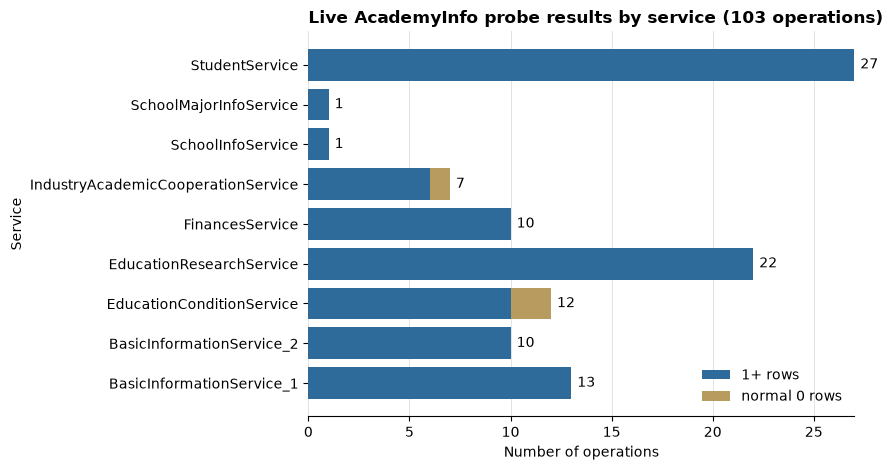

학과정보 totalCount: 60,919건
500행 페이지 1↔2 완전 동일 행 교집합: 13건
페이지 경계 중복이 관찰되어 자동 페이지 분할을 사용하지 않는다.
동시성 4: 대표 요청 8/8 통과


In [5]:
fig, ax = plt.subplots(figsize=(9, 4.8))
services = [row["service"] for row in service_summary]
with_rows = [row["with_rows"] for row in service_summary]
zero_rows = [row["zero_rows"] for row in service_summary]
ax.barh(services, with_rows, label="1+ rows", color="#2F6B9A")
ax.barh(services, zero_rows, left=with_rows, label="normal 0 rows", color="#B89B5E")
for index, row in enumerate(service_summary):
    ax.text(row["operations"] + 0.3, index, str(row["operations"]), va="center")
ax.set_title("Live AcademyInfo probe results by service (103 operations)", loc="left", weight="bold")
ax.set_xlabel("Number of operations")
ax.set_ylabel("Service")
ax.legend(frameon=False, loc="lower right")
ax.grid(axis="x", color="#D1D5DB", linewidth=0.7, alpha=0.7)
ax.set_axisbelow(True)
ax.spines[["top", "right", "left"]].set_visible(False)
plt.tight_layout()
plt.show()

if validation.page_boundary_duplicates:
    pagination_decision = "페이지 경계 중복이 관찰되어 자동 페이지 분할을 사용하지 않는다."
else:
    pagination_decision = "이번 500행 경계에서는 중복이 없었지만 과거 변동 이력 때문에 자동 페이지 분할은 보류한다."

print(f"학과정보 totalCount: {validation.school_major_total_count:,}건")
print(f"500행 페이지 1↔2 완전 동일 행 교집합: {validation.page_boundary_duplicates}건")
print(pagination_decision)
print(f"동시성 4: 대표 요청 {validation_result['concurrency_4_passed']} 통과")

## Checks

### 6. 전체 판정과 비산출물 원칙을 확인한다

In [6]:
display(validation_result)
print("최종 판정: AcademyInfo 9개 서비스·103개 기능의 현재 가용성 검증 통과")

{'run_started_at_utc': '2026-09-14T05:30:04.363607+00:00',
 'run_finished_at_utc': '2026-09-14T05:30:14.936138+00:00',
 'services': 9,
 'operations': 103,
 'operations_passed': 103,
 'operations_with_rows': 100,
 'operations_with_normal_zero_rows': 3,
 'year_omission_zero': '9/9',
 'school_omission_zero': '6/6',
 'multi_school_comma_pipe_unsupported': '6/6',
 'repeated_school_parameter_uses_first': '6/6',
 'school_major_total_count': 60919,
 'school_major_page_boundary_duplicates': 13,
 'concurrency_4_passed': '8/8',
 'created_data_files': 0}

최종 판정: AcademyInfo 9개 서비스·103개 기능의 현재 가용성 검증 통과


## Takeaways

- 103개 기능의 전체 데이터를 내려받지 않고도 한 번의 노트북 실행으로 현재 가용성과 요청 규칙을 검사할 수 있다.
- 학교별 기능은 학교코드 하나씩 요청하고, 조사연도가 필요한 기능은 연도를 명시한다.
- 대학명 생략이 전국 조회로 동작하는 기능과 학교코드 생략이 0건인 기능을 구분한다.
- 학과정보는 페이지 경계가 안정적이라고 다시 입증되기 전까지 한 번에 받는 전략을 유지한다.
- 이 노트북은 진단용이다. 실제 수집에서는 원본 응답과 별도 manifest를 보존해야 한다.